# Precipitation Distribution: Low vs High Resolution

Compare daily total precipitation (`PRECT = PRECC + PRECL`) between:
- **Low-res:** `c124_dyamond1_lr_clubbmf` (120 km)
- **High-res:** `cam77_dyamond1_prod1` (3.75 km)

Region: equatorial Africa (10°–50°E, 10°S–15°N). Data are from h0a (daily) files. Regional masking is applied before `.values` to stay memory-efficient.

In [1]:
from pathlib import Path
import yaml
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt


In [2]:
# ── CASE CONFIGURATION ────────────────────────────────────────────────────────
LR_CASE = "c124_dyamond1_lr_clubbmf"   # 120 km low-res reference
HR_CASE = "cam77_dyamond1_prod1"        # 3.75 km high-res production
STREAM  = "h0a"                         # daily 2D files for both cases

ARCHIVE = Path("/glade/campaign/cesm/km-scale/archive")

# Equatorial Africa region (0–360 lon convention)
REGION_LON = (10.0, 50.0)   # °E
REGION_LAT = (-10.0, 15.0)  # °N

# Rain/dry threshold
RAIN_THRESHOLD = 0.1   # mm/day

# m/s → mm/day conversion factor
MS_TO_MMDAY = 86400.0 * 1000.0

# ── YAML CONFIG ───────────────────────────────────────────────────────────────
_cfg_path = Path("/glade/u/home/brianpm/Code/hacknostics/util/km_scale_cases.yaml")
with open(_cfg_path) as _f:
    _cfg = yaml.safe_load(_f)

for _case in (LR_CASE, HR_CASE):
    _c = _cfg["cases"][_case]
    print(f"{_case}: grid={_c['grid']}, ncol={_c['ncol']:,}")


c124_dyamond1_lr_clubbmf: grid=mpasa120, ncol=40,962
cam77_dyamond1_prod1: grid=mpasa3p75, ncol=41,943,042


In [3]:
# ── FILE INVENTORY ────────────────────────────────────────────────────────────
lr_root = ARCHIVE / LR_CASE / "atm" / "hist"
hr_root = ARCHIVE / HR_CASE / "atm" / "hist"

lr_files = sorted(lr_root.glob(f"{LR_CASE}.cam.{STREAM}.*.nc"))
hr_files = sorted(hr_root.glob(f"{HR_CASE}.cam.{STREAM}.*.nc"))

print(f"LR files ({STREAM}): {len(lr_files)}")
if lr_files:
    print(f"  first: {lr_files[0].name}")
    print(f"  last:  {lr_files[-1].name}")
print(f"HR files ({STREAM}): {len(hr_files)}")
if hr_files:
    print(f"  first: {hr_files[0].name}")
    print(f"  last:  {hr_files[-1].name}")

# ── Load lat/lon once for each case (coordinates are constant across files) ────
_ds_lr = xr.open_dataset(lr_files[0], engine="netcdf4")
lat_lr = _ds_lr["lat"].values
lon_lr = _ds_lr["lon"].values
_ds_lr.close()

_ds_hr = xr.open_dataset(hr_files[0], engine="netcdf4")
lat_hr = _ds_hr["lat"].values
lon_hr = _ds_hr["lon"].values
_ds_hr.close()

# ── Regional boolean masks ─────────────────────────────────────────────────────
mask_lr = (
    (lon_lr >= REGION_LON[0]) & (lon_lr <= REGION_LON[1]) &
    (lat_lr >= REGION_LAT[0]) & (lat_lr <= REGION_LAT[1])
)
mask_hr = (
    (lon_hr >= REGION_LON[0]) & (lon_hr <= REGION_LON[1]) &
    (lat_hr >= REGION_LAT[0]) & (lat_hr <= REGION_LAT[1])
)

print(f"\nLR region cells: {mask_lr.sum():,} / {len(lat_lr):,}")
print(f"HR region cells: {mask_hr.sum():,} / {len(lat_hr):,}")
print(f"Region: lon {REGION_LON}°E, lat {REGION_LAT}°N")


LR files (h0a): 40
  first: c124_dyamond1_lr_clubbmf.cam.h0a.2016-08-02-00000.nc
  last:  c124_dyamond1_lr_clubbmf.cam.h0a.2016-09-10-00000.nc
HR files (h0a): 41
  first: cam77_dyamond1_prod1.cam.h0a.2016-08-01-00000.nc
  last:  cam77_dyamond1_prod1.cam.h0a.2016-09-10-00000.nc

LR region cells: 968 / 40,962
HR region cells: 993,696 / 41,943,042
Region: lon (10.0, 50.0)°E, lat (-10.0, 15.0)°N


In [4]:
# ── LOAD PRECT FOR EACH CASE ─────────────────────────────────────────────────
# Loop over daily files; extract only the regional subset each iteration.
# This keeps peak memory to (n_region_cells,) floats per file — never the full grid.

def load_prect_region(files, mask, label=""):
    """Return a 1-D array of all daily PRECT values (mm/day) within the mask."""
    chunks = []
    for i, f in enumerate(files):
        ds = xr.open_dataset(f, engine="netcdf4")
        # PRECC and PRECL are (time, ncol); take time index 0 (one timestep per daily file)
        precc = ds["PRECC"].isel(time=0).values[mask]  # m/s → masked region
        precl = ds["PRECL"].isel(time=0).values[mask]
        ds.close()
        prect_mmday = (precc + precl) * MS_TO_MMDAY
        chunks.append(prect_mmday)
        if (i + 1) % 10 == 0 or (i + 1) == len(files):
            print(f"  {label}: {i+1}/{len(files)} files loaded")
    return np.concatenate(chunks)

print("Loading LR PRECT...")
prect_lr = load_prect_region(lr_files, mask_lr, label="LR")
print(f"  → {prect_lr.shape[0]:,} values, range [{prect_lr.min():.4f}, {prect_lr.max():.2f}] mm/day")

print("\nLoading HR PRECT...")
prect_hr = load_prect_region(hr_files, mask_hr, label="HR")
print(f"  → {prect_hr.shape[0]:,} values, range [{prect_hr.min():.4f}, {prect_hr.max():.2f}] mm/day")


Loading LR PRECT...
  LR: 10/40 files loaded
  LR: 20/40 files loaded
  LR: 30/40 files loaded
  LR: 40/40 files loaded
  → 38,720 values, range [0.0000, 312.68] mm/day

Loading HR PRECT...
  HR: 10/41 files loaded
  HR: 20/41 files loaded
  HR: 30/41 files loaded
  HR: 40/41 files loaded
  HR: 41/41 files loaded
  → 40,741,536 values, range [0.0000, 372.27] mm/day


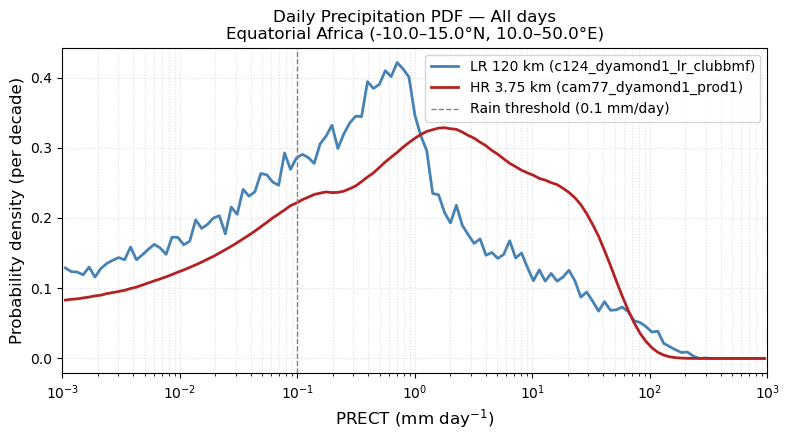

In [5]:
# ── PDF HELPER ───────────────────────────────────────────────────────────────
# Use log-spaced bins; normalize so the histogram integrates to 1 over log-space.
# We clip zeros (PRECT = 0 exactly) to avoid log(0) — they are counted separately.

LOG_BINS = np.logspace(-3, 3, 120)  # 0.001 to 1000 mm/day

def log_pdf(data, bins=LOG_BINS):
    """Histogram counts normalized so that sum(counts * bin_widths_log) = 1.
    Returns (bin_centers, density) in log-space.
    """
    pos = data[data > 0]
    counts, edges = np.histogram(pos, bins=bins)
    # Bin widths in log10 space
    log_widths = np.diff(np.log10(edges))
    density = counts / (counts.sum() * log_widths)
    centers = np.sqrt(edges[:-1] * edges[1:])  # geometric mean
    return centers, density

centers_lr_all, density_lr_all = log_pdf(prect_lr)
centers_hr_all, density_hr_all = log_pdf(prect_hr)

# ── PLOT: PDF of all days ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(centers_lr_all, density_lr_all, color="steelblue", lw=2,
        label=f"LR 120 km ({LR_CASE})")
ax.plot(centers_hr_all, density_hr_all, color="firebrick", lw=2,
        label=f"HR 3.75 km ({HR_CASE})")

ax.set_xscale("log")
ax.set_xlabel("PRECT (mm day$^{-1}$)", fontsize=12)
ax.set_ylabel("Probability density (per decade)", fontsize=12)
ax.set_title("Daily Precipitation PDF — All days\n"
             f"Equatorial Africa ({REGION_LAT[0]}–{REGION_LAT[1]}°N, "
             f"{REGION_LON[0]}–{REGION_LON[1]}°E)", fontsize=12)
ax.axvline(RAIN_THRESHOLD, color="gray", lw=1, ls="--", label=f"Rain threshold ({RAIN_THRESHOLD} mm/day)")
ax.legend(fontsize=10)
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.set_xlim(LOG_BINS[0], LOG_BINS[-1])

fig.tight_layout()
plt.show()


Dry-day fraction  LR: 0.497 (49.7%)
Dry-day fraction  HR: 0.514 (51.4%)
y_tick_max = np.float64(0.7)


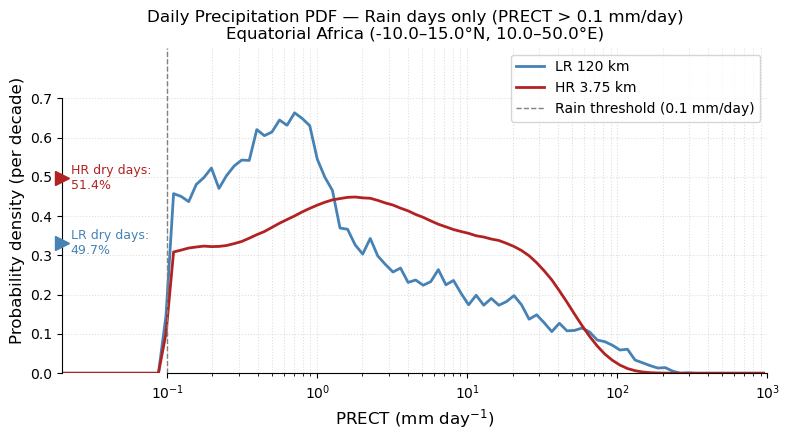

In [21]:
# ── RAIN-DAYS PDF + DRY-DAY FREQUENCY MARKERS ────────────────────────────────

# Dry-day fractions (PRECT <= threshold, including zeros)
dry_frac_lr = float(np.mean(prect_lr <= RAIN_THRESHOLD))
dry_frac_hr = float(np.mean(prect_hr <= RAIN_THRESHOLD))
print(f"Dry-day fraction  LR: {dry_frac_lr:.3f} ({dry_frac_lr*100:.1f}%)")
print(f"Dry-day fraction  HR: {dry_frac_hr:.3f} ({dry_frac_hr*100:.1f}%)")

# Rain-day PDFs (PRECT > threshold)
rain_lr = prect_lr[prect_lr > RAIN_THRESHOLD]
rain_hr = prect_hr[prect_hr > RAIN_THRESHOLD]
centers_lr_rain, density_lr_rain = log_pdf(rain_lr)
centers_hr_rain, density_hr_rain = log_pdf(rain_hr)

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

clr_lr = "steelblue"
clr_hr = "firebrick"

ax.plot(centers_lr_rain, density_lr_rain, color=clr_lr, lw=2,
        label=f"LR 120 km")
ax.plot(centers_hr_rain, density_hr_rain, color=clr_hr, lw=2,
        label=f"HR 3.75 km")

ax.set_xscale("log")

# ── Dry-day markers on left spine ─────────────────────────────────────────────
# Place markers as triangles at x = left axis limit, at y-heights proportional
# to their dry-day fraction (shown in data-space on a secondary y-axis annotation).
# We use ax.annotate with axes-fraction x-coordinate so they sit on the left spine.

leftside = 2e-2

ax.set_xlim(leftside, LOG_BINS[-1])
y_max = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0

y_max_val = max([density_lr_rain.max(), density_hr_rain.max()])

# Round UP to the nearest 10th
y_tick_max = np.ceil(y_max_val * 10) / 10
print(f"{y_tick_max = }")

# Compute y_max from the data for stable placement
y_max = max(density_lr_rain.max(), density_hr_rain.max()) * 1.25
ax.set_ylim(0, y_max)

# Marker y-positions: use dry_frac as fraction of y_max so they are visible
# and spaced apart; scale to ~35% and ~55% of y_max
for dry_frac, color, label, ypos_frac in [
    (dry_frac_lr, clr_lr, "LR", 0.40),
    (dry_frac_hr, clr_hr, "HR", 0.60),
]:
    ypos = ypos_frac * y_max
    # Triangle marker at left axis
    ax.plot(leftside, ypos, marker=">", ms=10, color=color, zorder=5,
            clip_on=False, transform=ax.transData)
    # Annotation text just to the right of the marker
    ax.annotate(
        f"{label} dry days:\n{dry_frac*100:.1f}%",
        xy=(leftside, ypos),
        xytext=(6, 0), textcoords="offset points",
        va="center", ha="left", fontsize=9, color=color,
    )

ax.axvline(RAIN_THRESHOLD, color="gray", lw=1, ls="--",
           label=f"Rain threshold ({RAIN_THRESHOLD} mm/day)")
ax.set_xlabel("PRECT (mm day$^{-1}$)", fontsize=12)
ax.set_ylabel("Probability density (per decade)", fontsize=12)
ax.set_title("Daily Precipitation PDF — Rain days only (PRECT > 0.1 mm/day)\n"
             f"Equatorial Africa ({REGION_LAT[0]}–{REGION_LAT[1]}°N, "
             f"{REGION_LON[0]}–{REGION_LON[1]}°E)", fontsize=12)
ax.legend(fontsize=10)
# Restrict ticks and grid to x >= 1e-1
ax.xaxis.set_major_locator(mpl.ticker.FixedLocator([1e-1, 1e0, 1e1, 1e2, 1e3]))
_minor_ticks = [s * 10**e for e in range(-1, 3) for s in range(2, 10)]
ax.xaxis.set_minor_locator(mpl.ticker.FixedLocator(_minor_ticks))

ax.set_yticks(np.arange(0,y_tick_max+0.1, 0.1))

ax.grid(True, which="both", ls=":", alpha=0.4)

ax.spines[['right', 'top']].set_visible(False)
ax.spines['bottom'].set_bounds([1e-1, 1e3])
ax.spines['left'].set_bounds([0, 0.7])


fig.tight_layout()
plt.show()
